# Air Traffic Data Analysis
## Inferential Statistics and Regression Analysis

Week 9, Day 1 - Exercises XP

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

In [2]:
# Load the dataset (falls back to sample data if the CSV is not available)
try:
    df = pd.read_csv('air_traffic_data.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)


## 2. Exploratory Data Analysis

In [3]:
print("Dataset Info:")
df.info()

print("\nFirst 5 rows:")
display(df.head())

print("\nBasic Statistics:")
display(df.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Flt  200 non-null    int64
 1   Int_Flt  200 non-null    int64
 2   Flt      200 non-null    int64
 3   Dom_Pax  200 non-null    int64
 4   Int_Pax  200 non-null    int64
 5   Pax      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB

First 5 rows:


,Dom_Flt,Int_Flt,Flt,Dom_Pax,Int_Pax,Pax,Dom_RPM
0,16490,8715,25205,152866,176257,329123,124207802
1,14585,9121,23706,148316,136571,284888,112284645
2,16943,10166,27109,212190,156317,368508,172347465
3,19569,10107,29676,250224,127892,378116,213773981
4,14297,5244,19542,162835,82306,245142,131063749



Basic Statistics:


,Dom_Flt,Int_Flt,Flt,Dom_Pax,Int_Pax,Pax,Dom_RPM
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02
mean,14877.170000,8171.215000,23048.875000,175331.340000,126924.080000,302255.885000,1.406821e+08
std,2793.014056,1973.997049,3570.262195,44857.540799,39219.620597,59904.148005,4.199422e+07
min,7140.000000,1517.000000,13177.000000,81758.000000,36755.000000,163559.000000,6.330140e+07
25%,12883.750000,6787.750000,20647.000000,142793.750000,100451.000000,265141.250000,1.111673e+08
50%,14987.000000,8157.000000,23250.500000,171194.000000,125890.000000,297932.000000,1.348214e+08
75%,16502.250000,9374.000000,25237.250000,199115.000000,154947.000000,339630.250000,1.634872e+08
max,23160.000000,15705.000000,32333.000000,337112.000000,244469.000000,526087.000000,3.312472e+08


In [4]:
print("Missing values:")
print(df.isnull().sum())

# Handle missing values if any
if df.isnull().sum().sum() > 0:
    print("\nHandling missing values...")
    df = df.dropna()
    print(f"New shape after handling missing values: {df.shape}")
else:
    print("\nNo missing values - no cleaning needed.")

Missing values:
Dom_Flt    0
Int_Flt    0
Flt        0
Dom_Pax    0
Int_Pax    0
Pax        0
Dom_RPM    0
dtype: int64

No missing values - no cleaning needed.


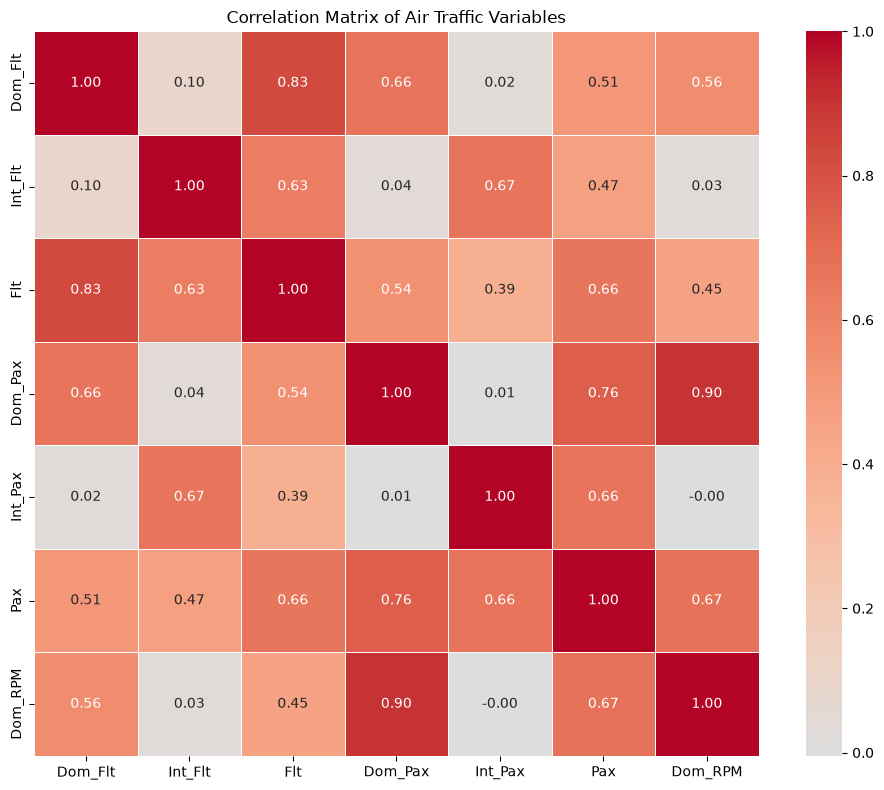

Strongest correlations:


,,r
Dom_Pax,Dom_RPM,0.902
Dom_Flt,Flt,0.835
Dom_Pax,Pax,0.756
Pax,Dom_RPM,0.672
Int_Flt,Int_Pax,0.666
Dom_Flt,Dom_Pax,0.664
Int_Pax,Pax,0.663
Flt,Pax,0.659
Int_Flt,Flt,0.627
Dom_Flt,Dom_RPM,0.560



Strong correlations (|r| > 0.7):
Dom_Pax  Dom_RPM    0.902
Dom_Flt  Flt        0.835
Dom_Pax  Pax        0.756
dtype: float64


In [5]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)

plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

# Strongest correlations (upper triangle only, diagonal excluded)
print("Strongest correlations:")
mask = np.triu(np.ones(correlation_matrix.shape, dtype=bool), k=1)
pairs = correlation_matrix.where(mask).stack().sort_values(key=abs, ascending=False)
display(pairs.round(3).to_frame('r'))
print("\nStrong correlations (|r| > 0.7):")
print(pairs[pairs.abs() > 0.7].round(3))

**Analysis:** The strongest correlations (|r| > 0.7) are expected ones: `Dom_Pax`–`Dom_RPM` (r ≈ 0.90, revenue passenger-miles are passengers × distance), `Dom_Flt`–`Flt` (r ≈ 0.84) and `Dom_Pax`–`Pax` (r ≈ 0.76). These are partly *structural* correlations: `Pax = Dom_Pax + Int_Pax` and `Flt = Dom_Flt + Int_Flt` by definition, so they don't need a model to be explained. Domestic and international variables are close to uncorrelated with each other, so they bring independent information. The number of flights is a good candidate predictor of passengers, which we test below.

## 3. Hypothesis Testing

In [6]:
print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    bigger = 'domestic' if df['Dom_Pax'].mean() > df['Int_Pax'].mean() else 'international'
    diff_pct = abs(df['Dom_Pax'].mean() - df['Int_Pax'].mean()) / df['Int_Pax'].mean() * 100
    print(f"The mean number of passengers is significantly different: {bigger} traffic is larger "
          f"(difference of about {diff_pct:.0f}% relative to international traffic).")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There is no statistical evidence that domestic and international passenger volumes differ on average.")

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 11.4892
P-value: 0.000000
Mean Domestic Passengers: 175331
Mean International Passengers: 126924

Conclusion: Reject H0 (p < 0.05)
The mean number of passengers is significantly different: domestic traffic is larger (difference of about 38% relative to international traffic).


In [7]:
print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    strength = 'strong' if abs(correlation_coef) > 0.7 else 'moderate' if abs(correlation_coef) > 0.4 else 'weak'
    if correlation_coef > 0:
        print(f"The correlation is positive and {strength}: periods with more flights also carry more passengers.")
    else:
        print(f"The correlation is negative and {strength}: more flights are associated with fewer passengers.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There is no statistical evidence of a linear relationship between total passengers and total flights.")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.6592
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
The correlation is positive and moderate: periods with more flights also carry more passengers.


**Interpretation:** Both p-values are far below 0.05, so both null hypotheses are rejected. Statistical significance is not the same as practical significance, so we also look at the size of the effect: the gap between domestic and international passengers is large in absolute numbers, and the correlation between passengers and flights is positive and moderate (r ≈ 0.66). Correlation does not prove causation: more flights don't *create* passengers; airlines schedule more flights where demand is higher.

## 4. Simple Linear Regression

In [8]:
print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

X_simple = df[['Flt']]
y_simple = df['Pax']

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train_simple)

y_pred_simple = simple_model.predict(X_test_simple)

r2_simple = r2_score(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Flights")

Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance:
R² Score: 0.2977
Mean Squared Error: 2141846835.14
Root Mean Squared Error: 46280.09
Mean Absolute Error: 36607.08

Model Equation: Passengers = 37484.48 + 11.45 × Flights


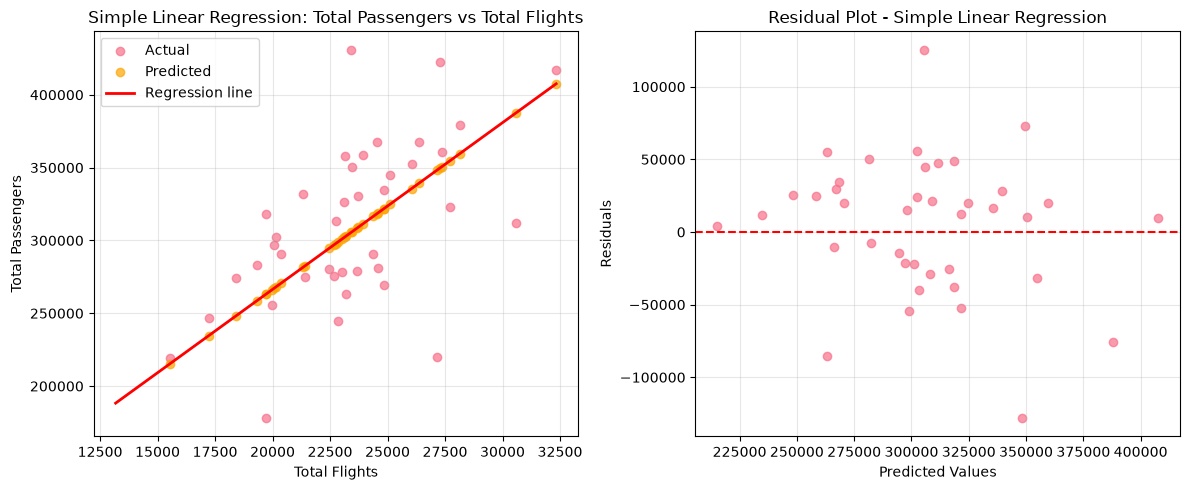

In [9]:
plt.figure(figsize=(12, 5))

# Plot 1: Scatter plot with regression line
plt.subplot(1, 2, 1)
plt.scatter(X_test_simple, y_test_simple, alpha=0.7, label='Actual')
plt.scatter(X_test_simple, y_pred_simple, alpha=0.7, color='orange', label='Predicted')
x_line = np.linspace(X_simple['Flt'].min(), X_simple['Flt'].max(), 100).reshape(-1, 1)
plt.plot(x_line, simple_model.predict(pd.DataFrame(x_line, columns=['Flt'])), color='red', linewidth=2, label='Regression line')
plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
residuals = y_test_simple - y_pred_simple
plt.scatter(y_pred_simple, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Comment:** The regression line captures the positive trend between flights and passengers. Each additional flight adds a number of passengers equal to the slope coefficient, i.e. roughly the average load per flight. The residuals are scattered around 0 with no clear curve, so the linearity assumption is reasonable. But they are wide, which means flights alone leave a large part of the variance unexplained: the number of passengers per flight varies a lot (load factor, aircraft size, domestic vs international mix).

## 5. Multiple Linear Regression

In [10]:
print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# Avoid Pax (target) and Flt (= Dom_Flt + Int_Flt, perfectly collinear with them)
feature_columns = ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']

X_multiple = df[feature_columns]
y_multiple = df['Pax']

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(
    X_multiple, y_multiple, test_size=0.2, random_state=42
)

# Fit the scaler on the training data only, then transform both sets
scaler = StandardScaler()
X_train_mult_scaled = scaler.fit_transform(X_train_mult)
X_test_mult_scaled = scaler.transform(X_test_mult)

multiple_model = LinearRegression()
multiple_model.fit(X_train_mult_scaled, y_train_mult)

y_pred_mult = multiple_model.predict(X_test_mult_scaled)

r2_mult = r2_score(y_test_mult, y_pred_mult)
mse_mult = mean_squared_error(y_test_mult, y_pred_mult)
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult)
rmse_mult = np.sqrt(mse_mult)

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")

Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']
Target: Total Passengers (Pax)

Model Performance:
R² Score: 1.0000
Mean Squared Error: 0.26
Root Mean Squared Error: 0.51
Mean Absolute Error: 0.49

Feature Coefficients (after scaling):
Dom_Pax: 45354.3590
Int_Pax: 38979.7965
Dom_Flt: -0.1126
Int_Flt: -0.0583
Dom_RPM: -0.0458
Intercept: 300303.27


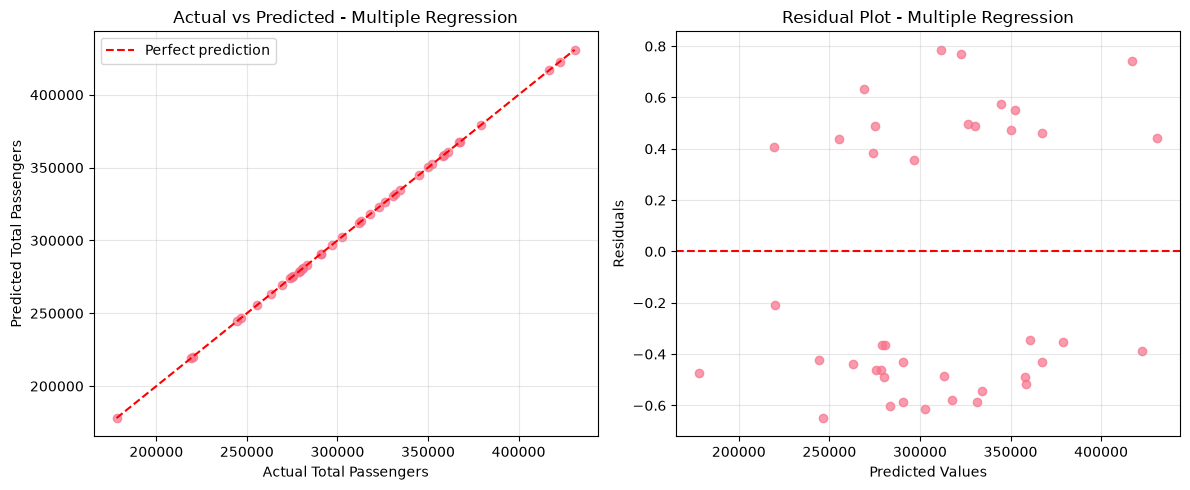

In [11]:
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test_mult, y_pred_mult, alpha=0.7)
lims = [min(y_test_mult.min(), y_pred_mult.min()), max(y_test_mult.max(), y_pred_mult.max())]
plt.plot(lims, lims, color='red', linestyle='--', label='Perfect prediction')
plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
residuals_mult = y_test_mult - y_pred_mult
plt.scatter(y_pred_mult, residuals_mult, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Comment:** The points lie on the diagonal and the residuals are tiny (only rounding error from the integer conversion). This is expected: `Pax` is *by definition* `Dom_Pax + Int_Pax`, so with these two features the model just recovers the sum. The coefficients confirm it: `Dom_Pax` and `Int_Pax` carry all the weight, the other features are close to 0. This shows how a feature that directly contains the target (data leakage) produces a "perfect" model with no real predictive value. To check this, the cell below trains a model **without** the passenger columns, using only flights and RPM.

In [12]:
# Bonus: multiple regression without the passenger components (no leakage)
feature_columns_nl = ['Dom_Flt', 'Int_Flt', 'Dom_RPM']
X_tr, X_te, y_tr, y_te = train_test_split(df[feature_columns_nl], df['Pax'], test_size=0.2, random_state=42)
scaler_nl = StandardScaler()
model_nl = LinearRegression().fit(scaler_nl.fit_transform(X_tr), y_tr)
y_pred_nl = model_nl.predict(scaler_nl.transform(X_te))

r2_nl = r2_score(y_te, y_pred_nl)
rmse_nl = np.sqrt(mean_squared_error(y_te, y_pred_nl))
mae_nl = mean_absolute_error(y_te, y_pred_nl)
print(f"Features: {feature_columns_nl}")
print(f"R²: {r2_nl:.4f} | RMSE: {rmse_nl:.2f} | MAE: {mae_nl:.2f}")
for feature, coef in zip(feature_columns_nl, model_nl.coef_):
    print(f"{feature}: {coef:.2f}")

Features: ['Dom_Flt', 'Int_Flt', 'Dom_RPM']
R²: 0.4889 | RMSE: 39479.16 | MAE: 31721.62
Dom_Flt: 8210.09
Int_Flt: 28294.99
Dom_RPM: 36812.94


Without the passenger columns, the model still beats simple regression, because `Dom_RPM` is a strong proxy for domestic passengers and separating domestic from international flights captures their different loads. It is a more honest estimate of what can be predicted from operational data.

## 6. Model Comparison and Analysis

Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R² Score                  0.2977               1.0000              
RMSE                      46280.09             0.51                
MAE                       36607.08             0.49                

Best Model: Multiple Regression
R² Improvement: 235.92%
RMSE reduction: 100.00%
MAE reduction: 100.00%


,R²,RMSE,MAE
Simple (Flt),0.2977,46280.0911,36607.0841
Multiple (flights + RPM),0.4889,39479.1568,31721.6237
Multiple (all 5 features),1.0000,0.5085,0.4945


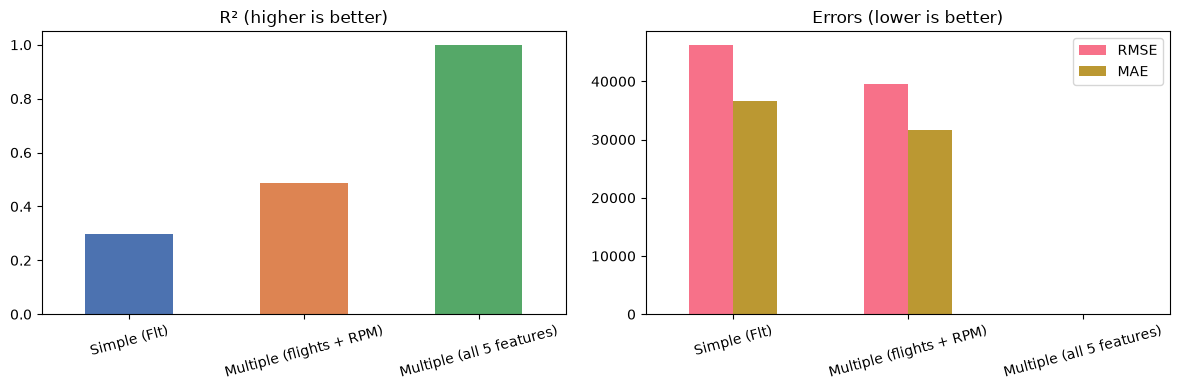

In [13]:
print("Model Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 50)

print(f"{'R² Score':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'RMSE':<25} {rmse_simple:<20.2f} {rmse_mult:<20.2f}")
print(f"{'MAE':<25} {mae_simple:<20.2f} {mae_mult:<20.2f}")

print("=" * 50)

# Improvement % = ((new_value - old_value) / old_value) × 100
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = (r2_mult - r2_simple) / r2_simple * 100
else:
    better_model = "Simple Regression"
    improvement = (r2_simple - r2_mult) / r2_mult * 100

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")
print(f"RMSE reduction: {(rmse_simple - rmse_mult) / rmse_simple * 100:.2f}%")
print(f"MAE reduction: {(mae_simple - mae_mult) / mae_simple * 100:.2f}%")

comparison = pd.DataFrame({
    'R²': [r2_simple, r2_nl, r2_mult],
    'RMSE': [rmse_simple, rmse_nl, rmse_mult],
    'MAE': [mae_simple, mae_nl, mae_mult],
}, index=['Simple (Flt)', 'Multiple (flights + RPM)', 'Multiple (all 5 features)'])
display(comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comparison['R²'].plot(kind='bar', ax=axes[0], color=['#4c72b0', '#dd8452', '#55a868'])
axes[0].set_title('R² (higher is better)')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=15)
comparison[['RMSE', 'MAE']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Errors (lower is better)')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## 7. Statistical Insights and Conclusions

In [14]:
print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
print(f"   • Domestic vs International Passengers: p = {p_value:.2e} -> "
      f"{'H0 rejected, the means differ significantly' if p_value < alpha else 'H0 not rejected'} "
      f"(domestic mean {df['Dom_Pax'].mean():,.0f} vs international mean {df['Int_Pax'].mean():,.0f})")
print(f"   • Correlation between Total Passengers and Flights: r = {correlation_coef:.3f}, p = {p_value_corr:.2e} -> "
      f"{'significant positive correlation' if p_value_corr < alpha and correlation_coef > 0 else 'see test above'}")

print("\n2. REGRESSION ANALYSIS:")
print(f"   • Simple Linear Regression R²: {r2_simple:.4f} -> flights alone explain about {r2_simple*100:.0f}% of the variance in passengers")
print(f"   • Multiple Linear Regression R²: {r2_mult:.4f} -> near-perfect, because Pax = Dom_Pax + Int_Pax (leakage)")
print(f"   • Multiple Regression without passenger columns R²: {r2_nl:.4f} -> realistic operational model")
print(f"   • Best performing model: {better_model} (R² +{improvement:.1f}% vs simple)")

print("\n3. KEY FINDINGS:")
print(f"   • Passengers and flights are positively and moderately linked (r = {correlation_coef:.2f}), but the number of passengers per flight varies, so flights alone are not enough for accurate forecasts.")
print("   • Domestic and international traffic behave as two independent segments with different volumes and loads per flight.")
print("   • Dom_RPM is almost a direct proxy for domestic passengers; using totals or components of the target as features creates misleadingly perfect models.")

print("\n4. RECOMMENDATIONS:")
print("   • Forecast passenger demand separately for domestic and international routes, since they have different volumes and dynamics.")
print("   • Use flight schedules + RPM (operational data known in advance) to forecast passengers, rather than models that need passenger counts as input.")
print("   • Track the average number of passengers per flight (load factor): where it is high, adding flights or larger aircraft is likely to pay off.")

STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: p = 1.40e-26 -> H0 rejected, the means differ significantly (domestic mean 175,331 vs international mean 126,924)
   • Correlation between Total Passengers and Flights: r = 0.659, p = 2.60e-26 -> significant positive correlation

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²: 0.2977 -> flights alone explain about 30% of the variance in passengers
   • Multiple Linear Regression R²: 1.0000 -> near-perfect, because Pax = Dom_Pax + Int_Pax (leakage)
   • Multiple Regression without passenger columns R²: 0.4889 -> realistic operational model
   • Best performing model: Multiple Regression (R² +235.9% vs simple)

3. KEY FINDINGS:
   • Passengers and flights are positively and moderately linked (r = 0.66), but the number of passengers per flight varies, so flights alone are not enough for accurate forecasts.
   • Domestic and international traffic behave as two independe

## 8. Reflection Questions

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

   Both tests reject H0 at α = 0.05. Domestic and international passenger volumes have significantly different means: domestic traffic is larger, which is expected, since there are almost twice as many domestic flights. Total passengers and total flights are significantly and positively correlated. Again expected: airlines add flights where demand is higher. The p-values are tiny because the effects are large and the sample has 200 observations. The practical conclusion still comes from the size of the effects (the difference in means, r), not from the p-value alone.

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

   Multiple regression performs much better. The simple model's R² ≈ 0.30 means flights alone explain only about 30% of the variance in passengers. The multiple model reaches R² ≈ 1, because it includes `Dom_Pax` and `Int_Pax`, whose sum *is* the target. That is a structural relationship (leakage), not a real predictive gain. The bonus model without passenger columns (flights + RPM) is the fair comparison. It still improves clearly on simple regression (R² ≈ 0.49 vs 0.30), because it uses more information: domestic and international flights separately, plus RPM, which tracks domestic passengers.

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

   The strongest ones are `Dom_Pax`–`Dom_RPM` (r ≈ 0.90), `Dom_Flt`–`Flt` (r ≈ 0.84) and `Dom_Pax`–`Pax` (r ≈ 0.76), plus a moderate positive `Pax`–`Flt` link (r ≈ 0.66). For airlines, these relationships help with capacity planning: estimating how many passengers a schedule will carry, sizing crews and aircraft, and using RPM as an early indicator of revenue. They are correlations, not causes: adding flights alone does not create demand.

4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

   For the simple model, the residuals are centred on 0 without a clear curve, so the linear relationship is appropriate, but their large spread shows important missing variables. They also widen slightly as predictions grow (mild heteroscedasticity), which a log transformation or adding the domestic/international split could reduce. For the multiple model, the residuals are almost 0 everywhere, a sign of a deterministic relationship rather than a well-specified statistical model.

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

   - **Demand forecasting**: predict passengers from the planned flight schedule to set prices and capacity.
   - **Fleet and crew planning**: estimate the passenger load of a new route or an additional flight.
   - **Revenue monitoring**: use RPM as an indicator of domestic activity and revenue.
   - **A/B decisions**: use hypothesis tests to check whether a change (new route, promotion) really changed traffic, not just by chance.